#### chair의 이미지 해상도 통알하여 적용하기

Test

In [32]:
from PIL import Image
import numpy as np

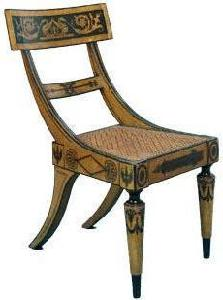

In [33]:
# chair의 1번 이미지
img = Image.open("../Data/chair/image_0001.jpg")
img

In [34]:
# 배열 크기 확인
np.array(img).shape

(300, 223, 3)

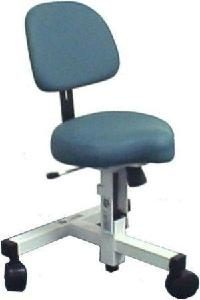

In [35]:
# chair의 2번 이미지
img2 = Image.open("../Data/chair/image_0002.jpg")
img2

> Image의 해상도가 일정하지 않음

전체 이미지의 해상도의 평균값을 가지고 적용해보자

#### Chair의 전체 이미지 평균 해상도 구하기

In [36]:
import glob

In [37]:
widthRatio = []
heightRatio = []

for file in sorted(glob.glob("../Data/chair/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   widthRatio.append(img.shape[1]) # w -> 1
   heightRatio.append(img.shape[0]) # h -> 0

In [38]:
print("chair의 너비 평균 해상도:", np.mean(widthRatio))
print("chair의 높이 평균 해상도:", np.mean(heightRatio))

chair의 너비 평균 해상도: 229.65
chair의 높이 평균 해상도: 297.31666666666666


> 너비 : 264, 높이: 284로 정함

** 해당 부분의 평균 겂이 다를 수 있음.
-> 너비 : 264, 높이: 284로 정함 의 경우 수업의 정도를 따라감

----
#### chair 이미지 해상도 및 흑백 이미지 변경

In [39]:
i = 1
for file in sorted(glob.glob("../Data/chair/*.jpg")):
   img = Image.open(file)
   imgResize = img.resize((264,284), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/chairNew/image_{i:02}.jpg", "JPEG")
   i+=1

----
#### laptop 이미지 해상도 및 흑백 이미지 변경

In [40]:
i = 1
for file in sorted(glob.glob("../Data/laptop/*.jpg")):
   img = Image.open(file)
   imgResize = img.resize((264,284), Image.Resampling.LANCZOS)
   imgResize = imgResize.convert('L')
   imgResize.save(f"../Data/laptopNew/image_{i:02}.jpg", "JPEG")
   i+=1

----
#### chair image를 Numpy로 변경하기

In [41]:
number_of_data = 60
img_width_size = 264
img_height_size = 284

In [42]:
chairData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
chairData.shape

(60, 284, 264)

In [43]:
i = 0
for file in sorted(glob.glob("../Data/chairNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   chairData[i,:,:] = img
   i+=1
chairData.shape

(60, 284, 264)

In [44]:
print(chairData[0].shape)

(284, 264)


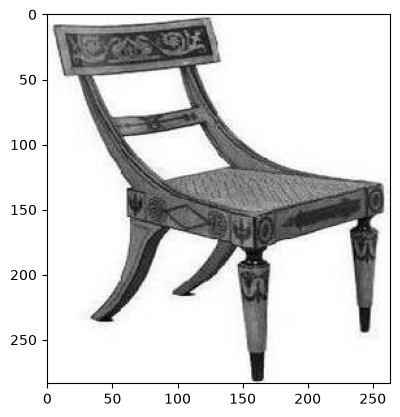

In [45]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(chairData[0].reshape(284,264), cmap='gray')
plt.show()

#### laptop Image를 Numpy 배열로 변경하기

In [46]:
laptopData = np.zeros(
   number_of_data * img_width_size * img_height_size,
   dtype=np.int32
).reshape(
   number_of_data,
   img_height_size,
   img_width_size
)
laptopData.shape

(60, 284, 264)

In [47]:
i = 0
for file in sorted(glob.glob("../Data/laptopNew/*.jpg")):
   img = np.array(Image.open(file), dtype=np.int32)
   laptopData[i,:,:] = img
   i+=1
laptopData.shape

(60, 284, 264)

In [48]:
print(laptopData[0].shape)

(284, 264)


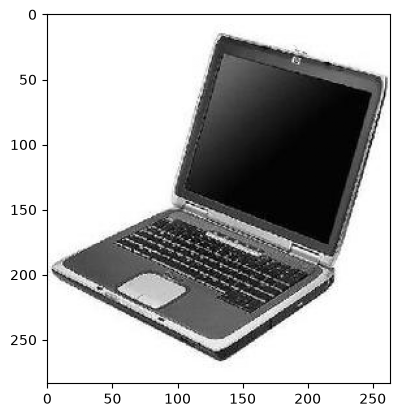

In [49]:
# 이미지 확인하기
import matplotlib.pyplot as plt

plt.imshow(laptopData[0].reshape(284,264), cmap='gray')
plt.show()

----
#### train data로 합치기


In [50]:
train = np.concatenate(
   [chairData, laptopData]
)
train.shape

(120, 284, 264)

In [51]:
target = np.concatenate(
   [np.zeros(60), np.ones(60)]
)
target.shape

(120,)

----
#### CNN으로 정확도 측정하기

- 정규화 및 채널 추가
- Train과 Test 분리
- CNN 만들기
- 시각화
- 평가(evaluate로 Train과 Test 평가)

In [52]:
# 정규화 및 채널추가
train = train.reshape(-1,img_height_size,img_width_size,1) / 255.0
train.shape

(120, 284, 264, 1)

In [53]:
# Train과 Test 분리
from sklearn.model_selection import train_test_split

train_data, test_data, train_target, test_target = \
   train_test_split(
      train,
      target,
      test_size=0.2,
      random_state=42
   )

In [54]:
print(train_data.shape)
print(test_data.shape)
print(train_target.shape)
print(test_target.shape)

(96, 284, 264, 1)
(24, 284, 264, 1)
(96,)
(24,)


In [55]:
# CNN 만들기
from tensorflow import keras
from tensorflow.keras.layers import Input

In [56]:
model = keras.Sequential()
model.add (
   Input(shape=(img_height_size,img_width_size,1))
)

model.add(
   keras.layers.Conv2D(
      32,
      kernel_size=3,
      activation='relu',
      padding='same'
   )
)

model.add(
   keras.layers.MaxPool2D(2)
)

model.add(
   keras.layers.Conv2D(
      64,
      kernel_size=3,
      activation='relu',
      padding='same'
   )
)

model.add(
   keras.layers.MaxPool2D(2)
)

In [57]:
model.add(
   keras.layers.Flatten()
)

model.add(
   keras.layers.Dense(100, activation='relu')
)

model.add(
   keras.layers.Dropout(0.5)
)

model.add(
   keras.layers.Dense(80, activation='relu')
)

model.add(
   keras.layers.Dropout(0.5)
)

model.add(
   keras.layers.Dense(
      1,
      activation='sigmoid'
   )
)

In [58]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 284, 264, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 142, 132, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 142, 132, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 71, 66, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 299904)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │    29,990,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 80)             │         8,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 80)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            81 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,017,477 (114.51 MB)

 Trainable params: 30,017,477 (114.51 MB)

 Non-trainable params: 0 (0.00 B)

In [59]:
model.compile(
   loss='binary_crossentropy',
   optimizer='adam',
   metrics=['accuracy']
)

checkpoint_cb = keras.callbacks.ModelCheckpoint("../Data/best_cnn_chair_laptop.keras")
early_stopping_cb = keras.callbacks.EarlyStopping(
   patience=7,
   restore_best_weights=True
)

In [60]:
history = model.fit(
   train_data,
   train_target,
   epochs=50, # 50
   validation_data=(test_data, test_target),
   callbacks=[checkpoint_cb, early_stopping_cb]
)

Epoch 1/50


3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5833 - loss: 3.0806 - val_accuracy: 0.5417 - val_loss: 3.0175
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.5104 - loss: 3.6744 - val_accuracy: 0.6250 - val_loss: 0.6272
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5521 - loss: 1.7701 - val_accuracy: 0.7083 - val_loss: 0.6564
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.5104 - loss: 0.7278 - val_accuracy: 0.5417 - val_loss: 0.6792
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.6146 - loss: 0.6740 - val_accuracy: 0.5417 - val_loss: 0.6811
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5729 - loss: 0.6690 - val_accuracy: 0.6667 - val_loss: 0.6766
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.5833 - loss: 0.6651 - val_accuracy: 0.7500 - val_loss: 0.6633
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 11s 4s/step - accuracy: 0.6771 - loss: 0.6350 - val_accuracy: 0.9167 - val_loss: 0.6328
Epoch 9/50
3/3 ━━━━

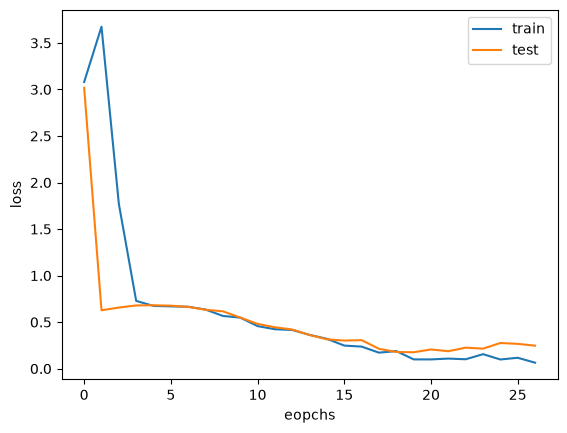

In [61]:
# 시각화
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('eopchs')
plt.ylabel('loss')
plt.legend(['train','test'])
plt.show()

In [62]:
# 평가
model.evaluate(train_data, train_target)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 768ms/step - accuracy: 1.0000 - loss: 0.0337


[0.033655066043138504, 1.0]

----

> ** 값과 표가 묘하게 이상하니 맹신하지 말고 주변 다른분 코드를 보고 수정하시길 바랍니다.